# 01. Data Cleaning & Memory Optimization

**Mục tiêu:**
1. Tối ưu bộ nhớ (downcasting int64→int32/int8, float64→float32)
2. Xử lý missing values (`days_since_prior_order`)
3. Merge products + aisles + departments
4. Integrity checks
5. Export to Parquet (định dạng hiệu năng cao)

In [20]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

# Add src to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Import utility functions from src/utils.py
from utils import reduce_mem_usage, safe_to_parquet  # type: ignore

# Directories
RAW_DIR = PROJECT_ROOT / "data" / "01_raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "02_processed"
VIZ_DIR = PROJECT_ROOT / "visualizations" / "01_data_cleaning"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print(f"RAW_DIR: {RAW_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")
print(f"VIZ_DIR: {VIZ_DIR}")

RAW_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\01_raw
PROCESSED_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\02_processed
VIZ_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\01_data_cleaning


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Bước 1: Load Raw Data với Memory Optimization

In [22]:
# Load orders với dtypes tối ưu ngay từ đầu
orders = pd.read_csv(
    RAW_DIR / "orders.csv",
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "eval_set": "category",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
    }
)
print(f"orders shape: {orders.shape}")
orders.info(memory_usage="deep")
orders.head()

orders shape: (3421083, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   user_id                 int32   
 2   eval_set                category
 3   order_number            int16   
 4   order_dow               int8    
 5   order_hour_of_day       int8    
 6   days_since_prior_order  float64 
dtypes: category(1), float64(1), int16(1), int32(2), int8(2)
memory usage: 68.5 MB


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [23]:
# Load products
products = pd.read_csv(
    RAW_DIR / "products.csv",
    dtype={
        "product_id": "int32",
        "aisle_id": "int16",
        "department_id": "int8",
    }
)
print(f"products shape: {products.shape}")
products.head()

products shape: (49688, 4)


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [24]:
# Load aisles & departments
aisles = pd.read_csv(
    RAW_DIR / "aisles.csv",
    dtype={"aisle_id": "int16"}
)
departments = pd.read_csv(
    RAW_DIR / "departments.csv",
    dtype={"department_id": "int8"}
)
print(f"aisles: {aisles.shape}, departments: {departments.shape}")

aisles: (134, 2), departments: (21, 2)


In [25]:
# Load order_products__prior (file lớn nhất - dùng chunking)
print("Loading order_products__prior...")
op_prior = pd.read_csv(
    RAW_DIR / "order_products__prior.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    }
)
print(f"order_products__prior shape: {op_prior.shape}")
op_prior.info(memory_usage="deep")
op_prior.head()

Loading order_products__prior...
order_products__prior shape: (32434489, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int32
 1   product_id         int32
 2   add_to_cart_order  int16
 3   reordered          int8 
dtypes: int16(1), int32(2), int8(1)
memory usage: 340.3 MB


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [27]:
# Load order_products__train
op_train = pd.read_csv(
    RAW_DIR / "order_products__train.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    }
)
print(f"order_products__train shape: {op_train.shape}")
op_train.head()

order_products__train shape: (1384617, 4)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


## Bước 2: Xử lý Missing Values

In [28]:
# Check missing values
print("Missing values in orders:")
print(orders.isnull().sum())
print(f"\ndays_since_prior_order: {orders['days_since_prior_order'].isnull().sum()} NaN values")
print("Đây là các đơn hàng đầu tiên của user (order_number=1)")

Missing values in orders:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

days_since_prior_order: 206209 NaN values
Đây là các đơn hàng đầu tiên của user (order_number=1)


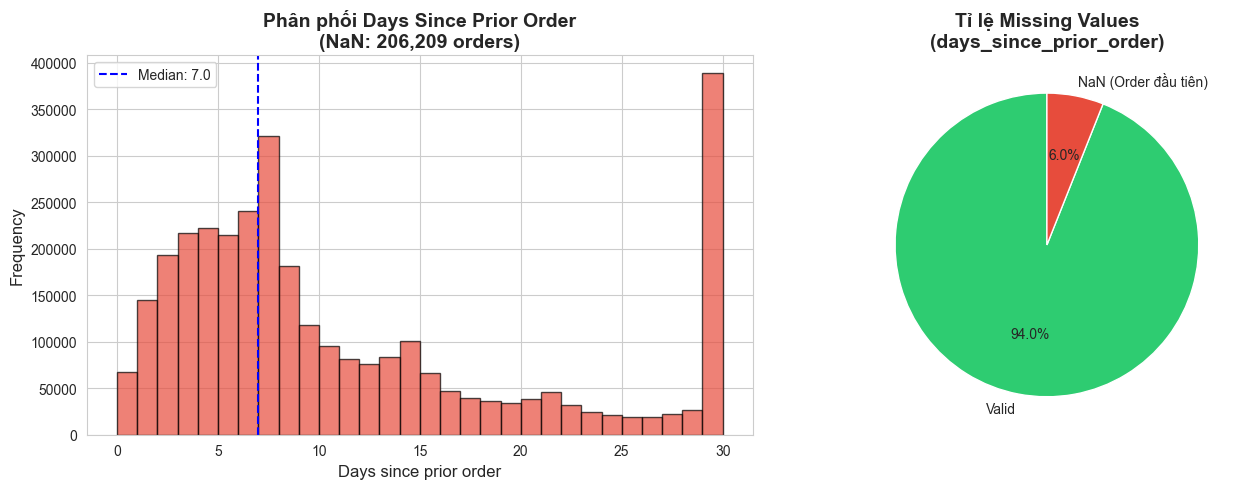

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\01_data_cleaning\03_missing_values_analysis.png


In [29]:
# Visualization: Missing values
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: days_since_prior_order (trước khi fill)
orders_temp = orders.copy()
orders_temp["days_since_prior_order_original"] = orders_temp["days_since_prior_order"]
orders_temp.loc[orders_temp["days_since_prior_order_original"] == -1, "days_since_prior_order_original"] = np.nan

ax[0].hist(orders_temp["days_since_prior_order_original"].dropna(), bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Days since prior order', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title(f'Phân phối Days Since Prior Order\n(NaN: {orders_temp["days_since_prior_order_original"].isna().sum():,} orders)', 
                fontsize=14, fontweight='bold')
ax[0].axvline(orders_temp["days_since_prior_order_original"].median(), color='blue', linestyle='--', 
              label=f'Median: {orders_temp["days_since_prior_order_original"].median():.1f}')
ax[0].legend()

# Pie: NaN vs Valid
nan_count = orders_temp["days_since_prior_order_original"].isna().sum()
valid_count = orders_temp["days_since_prior_order_original"].notna().sum()
ax[1].pie([valid_count, nan_count], labels=['Valid', 'NaN (Order đầu tiên)'], 
          autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[1].set_title('Tỉ lệ Missing Values\n(days_since_prior_order)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(VIZ_DIR / "03_missing_values_analysis.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {VIZ_DIR / '03_missing_values_analysis.png'}")

In [30]:
# Imputation: NaN → -1 (giúp model tree phân biệt "order đầu tiên")
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(-1).astype("float32")
print("✓ Đã thay NaN bằng -1")
print(orders["days_since_prior_order"].describe())

✓ Đã thay NaN bằng -1
count    3.421083e+06
mean     1.038460e+01
std      9.379136e+00
min     -1.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.500000e+01
max      3.000000e+01
Name: days_since_prior_order, dtype: float64


## Bước 3: Merge Products + Aisles + Departments (Denormalization)

In [31]:
# Merge để tạo bảng products đầy đủ metadata
products_full = products.merge(aisles, on="aisle_id", how="left") \
                        .merge(departments, on="department_id", how="left")

print(f"products_full shape: {products_full.shape}")
print("\nSample:")
products_full.head(10)

products_full shape: (49688, 6)

Sample:


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry
5,6,Dry Nose Oil,11,11,cold flu allergy,personal care
6,7,Pure Coconut Water With Orange,98,7,juice nectars,beverages
7,8,Cut Russet Potatoes Steam N' Mash,116,1,frozen produce,frozen
8,9,Light Strawberry Blueberry Yogurt,120,16,yogurt,dairy eggs
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7,water seltzer sparkling water,beverages


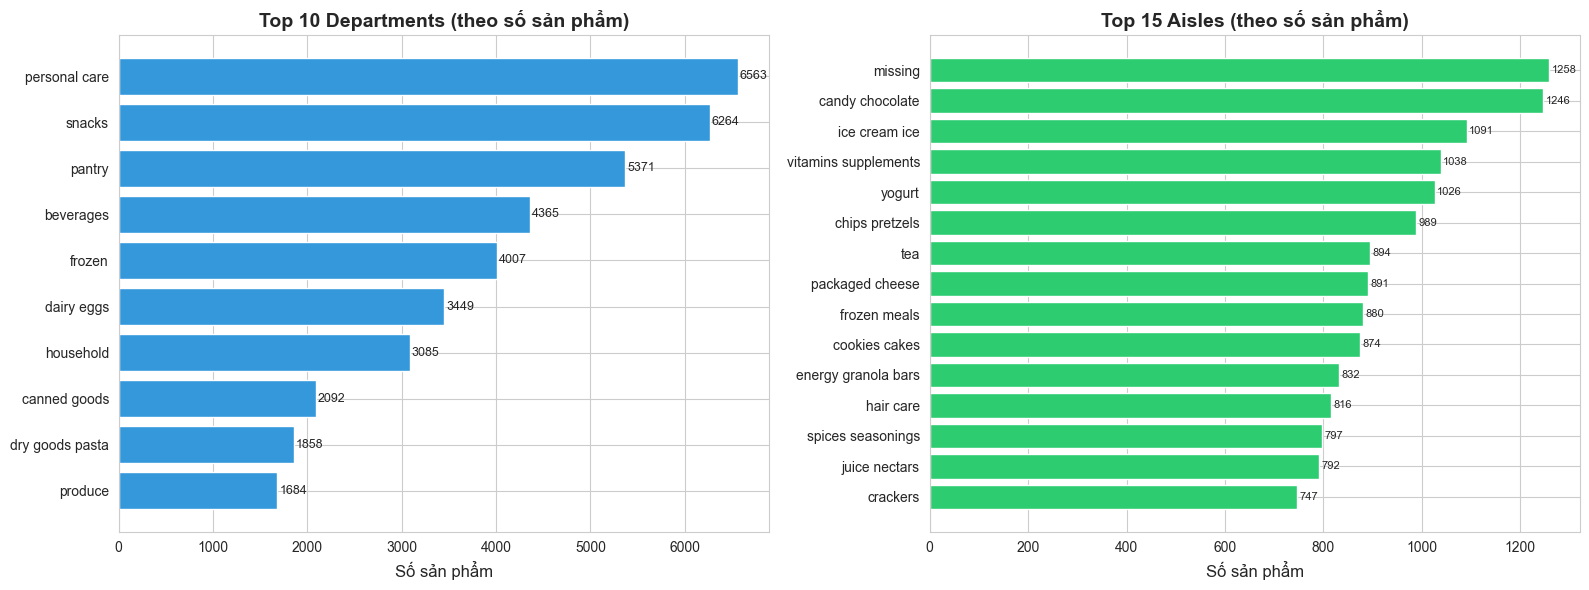

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\01_data_cleaning\02_top_departments_aisles.png


In [32]:
# Visualization: Top Departments & Aisles
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 departments
dept_counts = products_full['department'].value_counts().head(10)
ax[0].barh(dept_counts.index[::-1], dept_counts.values[::-1], color='#3498db')
ax[0].set_xlabel('Số sản phẩm', fontsize=12)
ax[0].set_title('Top 10 Departments (theo số sản phẩm)', fontsize=14, fontweight='bold')
for i, v in enumerate(dept_counts.values[::-1]):
    ax[0].text(v + 20, i, f'{v}', va='center', fontsize=9)

# Top 15 aisles
aisle_counts = products_full['aisle'].value_counts().head(15)
ax[1].barh(aisle_counts.index[::-1], aisle_counts.values[::-1], color='#2ecc71')
ax[1].set_xlabel('Số sản phẩm', fontsize=12)
ax[1].set_title('Top 15 Aisles (theo số sản phẩm)', fontsize=14, fontweight='bold')
for i, v in enumerate(aisle_counts.values[::-1]):
    ax[1].text(v + 5, i, f'{v}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(VIZ_DIR / "02_top_departments_aisles.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {VIZ_DIR / '02_top_departments_aisles.png'}")

In [33]:
# Check merge quality
print("\nKiểm tra merge:")
print(f"- Products không match aisle: {products_full['aisle'].isnull().sum()}")
print(f"- Products không match department: {products_full['department'].isnull().sum()}")
print("✓ Merge thành công!" if products_full['aisle'].isnull().sum() == 0 else "⚠ Có vấn đề merge")


Kiểm tra merge:
- Products không match aisle: 0
- Products không match department: 0
✓ Merge thành công!


## Bước 4: Integrity Checks

In [34]:
# Check 1: Phân phối eval_set
print("Phân phối eval_set:")
print(orders["eval_set"].value_counts())
print(f"\n% prior: {100*orders['eval_set'].value_counts(normalize=True).get('prior', 0):.1f}%")

Phân phối eval_set:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

% prior: 94.0%


In [35]:
# Check 2: Duplicate order_id
print(f"Duplicate order_id trong orders: {orders['order_id'].duplicated().sum()}")
print(f"Duplicate (order_id, product_id) trong op_prior: {op_prior[['order_id','product_id']].duplicated().sum()}")
print(f"Duplicate (order_id, product_id) trong op_train: {op_train[['order_id','product_id']].duplicated().sum()}")

Duplicate order_id trong orders: 0
Duplicate (order_id, product_id) trong op_prior: 0
Duplicate (order_id, product_id) trong op_train: 0


In [36]:
# Check 3: Khớp product_id giữa transactions và products
prod_ids_in_prior = set(op_prior["product_id"].unique())
prod_ids_in_train = set(op_train["product_id"].unique())
prod_ids_master = set(products_full["product_id"].unique())

orphan_prior = prod_ids_in_prior - prod_ids_master
orphan_train = prod_ids_in_train - prod_ids_master

print(f"Product IDs trong prior không có trong products: {len(orphan_prior)}")
print(f"Product IDs trong train không có trong products: {len(orphan_train)}")
print("✓ Data integrity OK!" if len(orphan_prior) == 0 and len(orphan_train) == 0 else "⚠ Có orphan products")

Product IDs trong prior không có trong products: 0
Product IDs trong train không có trong products: 0
✓ Data integrity OK!


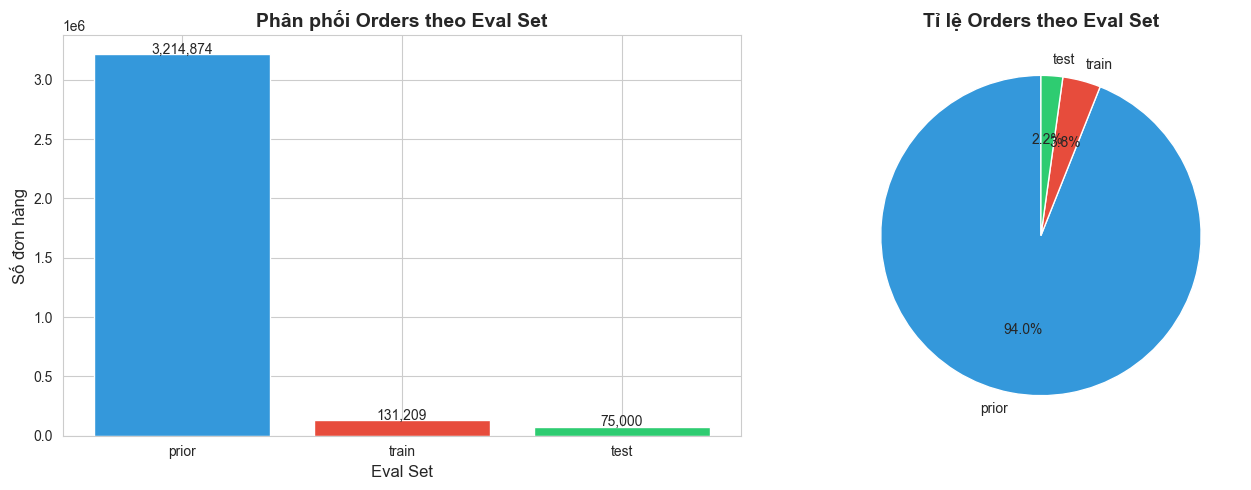

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\01_data_cleaning\01_eval_set_distribution.png


In [37]:
# Visualization: Phân phối eval_set
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
eval_counts = orders["eval_set"].value_counts()
ax[0].bar(eval_counts.index, eval_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
ax[0].set_xlabel('Eval Set', fontsize=12)
ax[0].set_ylabel('Số đơn hàng', fontsize=12)
ax[0].set_title('Phân phối Orders theo Eval Set', fontsize=14, fontweight='bold')
for i, v in enumerate(eval_counts.values):
    ax[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
ax[1].pie(eval_counts.values, labels=eval_counts.index, autopct='%1.1f%%', 
          colors=['#3498db', '#e74c3c', '#2ecc71'], startangle=90)
ax[1].set_title('Tỉ lệ Orders theo Eval Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(VIZ_DIR / "01_eval_set_distribution.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {VIZ_DIR / '01_eval_set_distribution.png'}")

## Bước 5: Export to Parquet

In [38]:
# Save cleaned data
safe_to_parquet(orders, PROCESSED_DIR / "orders.parquet")
safe_to_parquet(products_full, PROCESSED_DIR / "products.parquet")
safe_to_parquet(op_prior, PROCESSED_DIR / "order_products__prior.parquet")
safe_to_parquet(op_train, PROCESSED_DIR / "order_products__train.parquet")

print("\n✅ Data cleaning hoàn tất! Đã lưu vào 02_processed/")

Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\02_processed\orders.parquet
Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\02_processed\products.parquet
Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\02_processed\order_products__prior.parquet
Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\02_processed\order_products__train.parquet

✅ Data cleaning hoàn tất! Đã lưu vào 02_processed/
